# Deep Q-Network (DQN): Q-Learning Meets Deep Learning

**A hands-on tutorial with theory and PyTorch implementation**

---

In 2013 a small London startup called DeepMind posted a paper showing a single neural network learning to play seven
Atari 2600 games *from raw pixels*, several of them better than a human expert
([Mnih et al., 2013](https://arxiv.org/abs/1312.5602)). The 2015 *Nature* follow-up scaled the result to 49 games with one
architecture and one set of hyperparameters ([Mnih et al., 2015](https://www.nature.com/articles/nature14236)). This was
the moment "deep reinforcement learning" became a field: the **Deep Q-Network (DQN)** demonstrated that Q-learning —
a 25-year-old tabular algorithm — could drive a deep convolutional network end-to-end, provided two stabilizing tricks:
**experience replay** and a **target network**.

Nearly every value-based method since (Double DQN, Dueling, Prioritized Replay, Rainbow, R2D2, Agent57) is DQN plus one
idea. This notebook builds DQN from scratch, explains *why* the two tricks are necessary, and adds **Double DQN** as the
first and most important refinement.

## What you will learn

1. Why naive Q-learning with a neural network diverges: the **deadly triad**.
2. **Experience replay**: breaking correlations and reusing data.
3. **Target networks**: stabilizing the bootstrap target.
4. A **from-scratch PyTorch implementation** on `CartPole-v1`, with the training tricks used in practice.
5. **Double DQN** and the over-estimation problem.
6. How DQN relates to the rest of the deep RL landscape.

## Notebook outline

1. From Q-learning to function approximation
2. The deadly triad and why naive deep Q-learning fails
3. DQN's two stabilizers: experience replay and the target network
4. The DQN algorithm and loss
5. Double DQN
6. Implementation
7. Training and results
8. **Visual demonstration** of the trained agent
9. Strengths, weaknesses & connections
10. References

## 0. Setup

We use PyTorch for function approximation, `gymnasium` (the maintained fork of OpenAI Gym) for environments,
`pygame` for rendering frames, and `imageio` to turn rendered frames into GIFs. If you don't have these installed,
uncomment the install cell.

In [1]:
# !pip install torch gymnasium pygame imageio matplotlib numpy

In [2]:
import math
import random
import time
import warnings
from collections import deque
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="pkg_resources is deprecated")   # noisy pygame import warning

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}, gymnasium version: {gym.__version__}")

Using device: cpu
PyTorch version: 2.11.0, gymnasium version: 1.2.3


### Visualization helpers

Every tutorial in this folder ends with a *visual demonstration* of the trained agent. The three helpers below are
shared across notebooks:

- `record_episode` rolls out one episode with a given action function and collects rendered RGB frames.
- `show_filmstrip` shows a handful of evenly spaced frames as a static image (renders everywhere, including GitHub).
- `save_gif` writes an animated GIF to `media/` and displays it inline.

In [3]:
import os
import imageio.v3 as iio
from IPython.display import Image, display

MEDIA_DIR = "media"
os.makedirs(MEDIA_DIR, exist_ok=True)


def record_episode(env, act_fn, seed=0, max_steps=1000):
    """Roll out one episode in an env created with render_mode="rgb_array".

    `act_fn(obs) -> action`. Returns (frames, episode_return, episode_length).
    """
    obs, _ = env.reset(seed=seed)
    frames, ep_ret = [env.render()], 0.0
    for _ in range(max_steps):
        obs, reward, terminated, truncated, _ = env.step(act_fn(obs))
        ep_ret += reward
        frames.append(env.render())
        if terminated or truncated:
            break
    return frames, ep_ret, len(frames) - 1


def show_filmstrip(frames, n=8, title=None, captions=None):
    """Static preview: n evenly spaced frames side by side."""
    idx = np.linspace(0, len(frames) - 1, num=min(n, len(frames)), dtype=int)
    h, w = np.asarray(frames[0]).shape[:2]
    fw = 2.3
    fig, axes = plt.subplots(1, len(idx), figsize=(fw * len(idx), fw * h / w + 0.6))
    for ax, i in zip(np.atleast_1d(axes), idx):
        ax.imshow(frames[i])
        ax.axis("off")
        ax.set_title(captions[i] if captions is not None else f"t = {i}", fontsize=9)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def save_gif(frames, name, fps=30, max_frames=240, downscale=2):
    """Subsample/downscale frames, write media/<name>.gif and return an inline Image."""
    step = max(1, int(np.ceil(len(frames) / max_frames)))
    small = np.stack([np.asarray(f)[::downscale, ::downscale] for f in frames[::step]])
    path = os.path.join(MEDIA_DIR, f"{name}.gif")
    iio.imwrite(path, small, duration=int(1000 * step / fps), loop=0)
    print(f"Saved {path}  ({small.shape[0]} frames, {os.path.getsize(path) / 1e6:.2f} MB)")
    return Image(filename=path)

In [4]:
def moving_average(x, w=20):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")

## 1. From Q-Learning to Function Approximation

Tabular Q-learning updates one cell of a table:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha\big[\, r + \gamma \max_{a'} Q(s',a') - Q(s,a) \,\big].
$$

For Atari, a "state" is a stack of four $84 \times 84$ grayscale frames — far too many states for a table, and a table
would not *generalize* between similar screens anyway. So we approximate $Q(s,a) \approx Q_\theta(s,a)$ with a neural
network that takes the state and outputs one value per action, and replace the tabular update with a gradient step on
the squared TD error:

$$
L(\theta) \;=\; \Big(\, \underbrace{r + \gamma \max_{a'} Q_\theta(s',a')}_{\text{target } y} \;-\; Q_\theta(s,a) \Big)^2, \qquad
\theta \leftarrow \theta - \alpha \nabla_\theta L(\theta).
$$

The gradient is taken only through $Q_\theta(s,a)$, not through the target — this is a *semi-gradient* method, exactly
like tabular Q-learning treats the target as a fixed number.

**Important:** This is *not* supervised learning. The target $y$ depends on the very parameters we are updating, the data
distribution depends on the policy (which depends on $\theta$), and consecutive samples are strongly correlated.

## 2. The Deadly Triad

Sutton & Barto call the combination of three ingredients the **deadly triad**:

1. **Function approximation** (a neural network instead of a table),
2. **Bootstrapping** (targets built from our own estimates, $\gamma \max_{a'} Q_\theta(s',a')$),
3. **Off-policy learning** (learning about the greedy policy from $\varepsilon$-greedy or replayed data).

Any two are fine; all three together can make the value estimates *diverge*, even for linear function approximation
(Baird's counterexample, 1995). Neural networks add two more practical problems:

- **Correlated samples.** Consecutive transitions from one episode are nearly identical. SGD assumes i.i.d. data;
  feeding it a highly correlated stream causes it to over-fit to the most recent experience and forget the rest.
- **Moving targets.** Every gradient step changes $Q_\theta$, which changes the targets for *all* other samples, which
  can set up a feedback loop: over-estimated $Q(s')$ raises the target for $Q(s)$, which raises targets further upstream, …

DQN's contribution was to show that two simple engineering ideas tame both problems well enough to work at scale.

## 3. DQN's Two Stabilizers

### 3.1 Experience replay (Lin, 1992)

Store every transition $(s, a, r, s', \text{done})$ in a large FIFO **replay buffer** $\mathcal{D}$ (1M transitions for
Atari). At each training step, sample a random **minibatch** from $\mathcal{D}$ and take a gradient step on it.

- **Decorrelates** the samples: a minibatch mixes transitions from many different episodes and policies.
- **Reuses** each transition many times, greatly improving data efficiency over online Q-learning.
- Smooths the training distribution over many past behaviors, avoiding oscillation/feedback loops.

Replay is only possible because Q-learning is **off-policy** — the update does not care which policy produced $(s,a,r,s')$.
An on-policy method like SARSA or REINFORCE could not use old data this way.

### 3.2 Target network

Keep a second copy of the network, $Q_{\theta^-}$, whose parameters are **frozen** and only copied from $\theta$ every
$C$ steps (10,000 in the Nature paper). Compute targets with the frozen copy:

$$
y \;=\; r + \gamma \max_{a'} Q_{\theta^-}(s', a').
$$

For $C$ steps the regression target is *fixed*, which turns the problem into a sequence of ordinary supervised learning
problems and breaks the feedback loop. A common modern alternative is a **Polyak-averaged** target,
$\theta^- \leftarrow \tau\theta + (1-\tau)\theta^-$ with $\tau \approx 0.005$, updated every step.

## 4. The DQN Algorithm

$$
\boxed{\;
L(\theta) \;=\; \mathbb{E}_{(s,a,r,s',d) \sim \mathcal{D}}\Big[\, \ell_\delta\big(\, r + \gamma\,(1-d)\, \max_{a'} Q_{\theta^-}(s',a') \;-\; Q_\theta(s,a) \,\big) \Big]
\;}
$$

where $d$ is the done flag (no bootstrap after a terminal state) and $\ell_\delta$ is the **Huber loss** (quadratic for
small errors, linear for large ones), which the Nature paper used as "error clipping" to keep large TD errors from
producing huge gradients.

**Algorithm (one training step):**

1. Choose $a_t$ $\varepsilon$-greedily from $Q_\theta(s_t, \cdot)$, with $\varepsilon$ annealed from 1.0 to a small value.
2. Execute $a_t$, observe $r_t, s_{t+1}, d_t$; store $(s_t, a_t, r_t, s_{t+1}, d_t)$ in $\mathcal{D}$.
3. Sample a minibatch from $\mathcal{D}$, compute targets with $Q_{\theta^-}$, take a gradient step on $L(\theta)$.
4. Every $C$ steps set $\theta^- \leftarrow \theta$.

Atari-specific details (frame skipping, stacking 4 frames, reward clipping to $\{-1, 0, 1\}$, the 3-layer CNN) are
orthogonal to the algorithm and we skip them; on CartPole an MLP on the 4-dimensional state suffices.

## 5. Double DQN

The $\max_{a'}$ in the target is taken over *noisy estimates*, and $\mathbb{E}[\max_a X_a] \ge \max_a \mathbb{E}[X_a]$
— so the target is systematically **over-estimated** (Thrun & Schwartz, 1993). Over-estimation is not fatal if it is
uniform, but it never is, and it can push the greedy policy toward wrong actions.

**Double Q-learning** (van Hasselt, 2010) decouples *selecting* the maximizing action from *evaluating* it, using two
independent estimators. **Double DQN** (van Hasselt, Guez & Silver, 2016) observed that DQN already has two networks —
so select with the online network and evaluate with the target network:

$$
y^{\text{DDQN}} \;=\; r + \gamma\,(1-d)\; Q_{\theta^-}\!\big(s',\; \arg\max_{a'} Q_\theta(s',a')\big).
$$

A one-line change that substantially improved Atari scores and made the learned values far more accurate. We implement
it as a flag and compare the two.

## 6. Implementation

### 6.1 Hyperparameters

CartPole is small, so we use a shorter schedule than Atari. The structure is identical to the original.

In [5]:
@dataclass
class DQNConfig:
    env_id: str = "CartPole-v1"
    total_timesteps: int = 60_000
    buffer_size: int = 50_000
    batch_size: int = 64
    learning_starts: int = 1_000     # fill the buffer with random experience first
    train_frequency: int = 1         # gradient step every k env steps
    target_update_interval: int = 500   # C: hard-copy online -> target every C steps
    gamma: float = 0.99
    lr: float = 5e-4
    epsilon_start: float = 1.0
    epsilon_end: float = 0.05
    epsilon_decay_steps: int = 20_000
    hidden: int = 128
    max_grad_norm: float = 10.0
    double_dqn: bool = False         # switch to the Double DQN target
    eval_interval: int = 2_500       # greedy evaluation every k steps
    eval_episodes: int = 10


def linear_schedule(start, end, duration, t):
    return end + (start - end) * max(0.0, 1 - t / duration)

### 6.2 Q-network and replay buffer

The network maps an observation to one Q-value per action. The replay buffer is a set of preallocated NumPy arrays
with a circular write pointer — simple and fast.

In [6]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, n_actions))

    def forward(self, obs):
        return self.net(obs)


class ReplayBuffer:
    def __init__(self, capacity, obs_dim):
        self.capacity, self.ptr, self.size = capacity, 0, 0
        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros(capacity, dtype=np.int64)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.dones = np.zeros(capacity, dtype=np.float32)

    def add(self, obs, action, reward, next_obs, done):
        i = self.ptr
        self.obs[i], self.actions[i], self.rewards[i], self.next_obs[i], self.dones[i] = obs, action, reward, next_obs, done
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        to_t = lambda x: torch.as_tensor(x[idx], device=device)
        return to_t(self.obs), to_t(self.actions), to_t(self.rewards), to_t(self.next_obs), to_t(self.dones)

### 6.3 The DQN update

This is the heart of the algorithm. Note the `torch.no_grad()` around the target computation (semi-gradient), the
`(1 - dones)` mask, and the two target variants.

In [7]:
def dqn_update(q_net, target_net, optimizer, batch, cfg):
    obs, actions, rewards, next_obs, dones = batch

    with torch.no_grad():
        if cfg.double_dqn:
            # Double DQN: select a' with the online net, evaluate it with the target net
            next_actions = q_net(next_obs).argmax(dim=1, keepdim=True)
            next_q = target_net(next_obs).gather(1, next_actions).squeeze(1)
        else:
            # Vanilla DQN: max over the target net's own values
            next_q = target_net(next_obs).max(dim=1).values
        targets = rewards + cfg.gamma * (1.0 - dones) * next_q

    q_values = q_net(obs).gather(1, actions.unsqueeze(1)).squeeze(1)   # Q_theta(s, a) for the taken actions
    loss = F.smooth_l1_loss(q_values, targets)                          # Huber loss

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(q_net.parameters(), cfg.max_grad_norm)
    optimizer.step()
    return loss.item(), q_values.mean().item()

### 6.4 The training loop

Besides the algorithm itself, the loop does three things that make the results interpretable:

- **Periodic greedy evaluation** ($\varepsilon = 0$) on a separate environment, so the learning curve is not confounded
  by exploration noise. We keep the **best** checkpoint for the demo — DQN on CartPole is notorious for occasionally
  "forgetting" a good policy late in training.
- **Tracking $\max_a Q$ on a fixed set of held-out states**, exactly as in Figure 2 of the Nature paper: it shows whether
  the value estimates are stable and, later, whether Double DQN reduces over-estimation.
- Logging the **training loss**.

In [8]:
def evaluate_greedy(q_net, env_id, n_episodes=10, seed=10_000):
    env = gym.make(env_id)
    returns = []
    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed + i)
        done, ep_ret = False, 0.0
        while not done:
            with torch.no_grad():
                action = int(q_net(torch.as_tensor(obs, dtype=torch.float32, device=device)).argmax().item())
            obs, r, terminated, truncated, _ = env.step(action)
            ep_ret += r
            done = terminated or truncated
        returns.append(ep_ret)
    env.close()
    return float(np.mean(returns))


def train_dqn(cfg: DQNConfig, seed=SEED, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    env = gym.make(cfg.env_id)
    env = gym.wrappers.RecordEpisodeStatistics(env)
    obs_dim, n_actions = env.observation_space.shape[0], env.action_space.n

    q_net = QNetwork(obs_dim, n_actions, cfg.hidden).to(device)
    target_net = QNetwork(obs_dim, n_actions, cfg.hidden).to(device)
    target_net.load_state_dict(q_net.state_dict())
    optimizer = torch.optim.Adam(q_net.parameters(), lr=cfg.lr)
    buffer = ReplayBuffer(cfg.buffer_size, obs_dim)

    # Held-out states for tracking max_a Q (collected with a random policy, as in the Nature paper)
    probe_env = gym.make(cfg.env_id); probe_states = []
    o, _ = probe_env.reset(seed=seed + 1)
    while len(probe_states) < 500:
        probe_states.append(o); o, _, term, trunc, _ = probe_env.step(probe_env.action_space.sample())
        if term or trunc: o, _ = probe_env.reset()
    probe_states = torch.as_tensor(np.array(probe_states), dtype=torch.float32, device=device)

    logs = dict(step=[], loss=[], probe_q=[], eval_step=[], eval_return=[], train_returns=[], train_return_steps=[])
    best_return, best_state = -np.inf, None
    obs, _ = env.reset(seed=seed); env.action_space.seed(seed)

    for step in range(1, cfg.total_timesteps + 1):
        epsilon = linear_schedule(cfg.epsilon_start, cfg.epsilon_end, cfg.epsilon_decay_steps, step)
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                action = int(q_net(torch.as_tensor(obs, dtype=torch.float32, device=device)).argmax().item())

        next_obs, reward, terminated, truncated, info = env.step(action)
        buffer.add(obs, action, reward, next_obs, float(terminated))   # bootstrap through time-limit truncation
        obs = next_obs
        if terminated or truncated:
            logs["train_returns"].append(float(info["episode"]["r"])); logs["train_return_steps"].append(step)
            obs, _ = env.reset()

        if step > cfg.learning_starts and step % cfg.train_frequency == 0:
            loss, _ = dqn_update(q_net, target_net, optimizer, buffer.sample(cfg.batch_size), cfg)
            if step % 100 == 0:
                with torch.no_grad():
                    probe_q = q_net(probe_states).max(1).values.mean().item()
                logs["step"].append(step); logs["loss"].append(loss); logs["probe_q"].append(probe_q)

        if step % cfg.target_update_interval == 0:
            target_net.load_state_dict(q_net.state_dict())

        if step % cfg.eval_interval == 0:
            ret = evaluate_greedy(q_net, cfg.env_id, cfg.eval_episodes)
            logs["eval_step"].append(step); logs["eval_return"].append(ret)
            if ret >= best_return:
                best_return, best_state = ret, {k: v.clone() for k, v in q_net.state_dict().items()}
            if verbose:
                print(f"step {step:6d} | eps {epsilon:.2f} | greedy eval return {ret:6.1f} | probe max-Q {logs['probe_q'][-1]:.2f}")

    env.close()
    best_net = QNetwork(obs_dim, n_actions, cfg.hidden).to(device)
    best_net.load_state_dict(best_state)
    return q_net, best_net, logs

## 7. Training and Results

We train vanilla DQN and Double DQN with identical seeds and hyperparameters. On CartPole-v1 the maximum return is 500.

In [9]:
runs = {}
for name, double in [("DQN", False), ("Double DQN", True)]:
    print(f"===== {name} =====")
    t0 = time.time()
    cfg = DQNConfig(double_dqn=double)
    final_net, best_net, logs = train_dqn(cfg, verbose=True)
    runs[name] = dict(final=final_net, best=best_net, logs=logs)
    print(f"{name}: {time.time() - t0:.0f}s, best greedy eval return = {max(logs['eval_return']):.1f}\n")

===== DQN =====


step   2500 | eps 0.88 | greedy eval return  137.1 | probe max-Q 2.91


step   5000 | eps 0.76 | greedy eval return  204.3 | probe max-Q 7.52


step   7500 | eps 0.64 | greedy eval return  171.6 | probe max-Q 12.02


step  10000 | eps 0.53 | greedy eval return   79.8 | probe max-Q 16.21


...

step  50000 | eps 0.05 | greedy eval return  500.0 | probe max-Q 64.97


step  52500 | eps 0.05 | greedy eval return  500.0 | probe max-Q 66.92


step  55000 | eps 0.05 | greedy eval return  500.0 | probe max-Q 68.50


step  57500 | eps 0.05 | greedy eval return  500.0 | probe max-Q 70.09


step  60000 | eps 0.05 | greedy eval return  495.0 | probe max-Q 71.92
Double DQN: 30s, best greedy eval return = 500.0



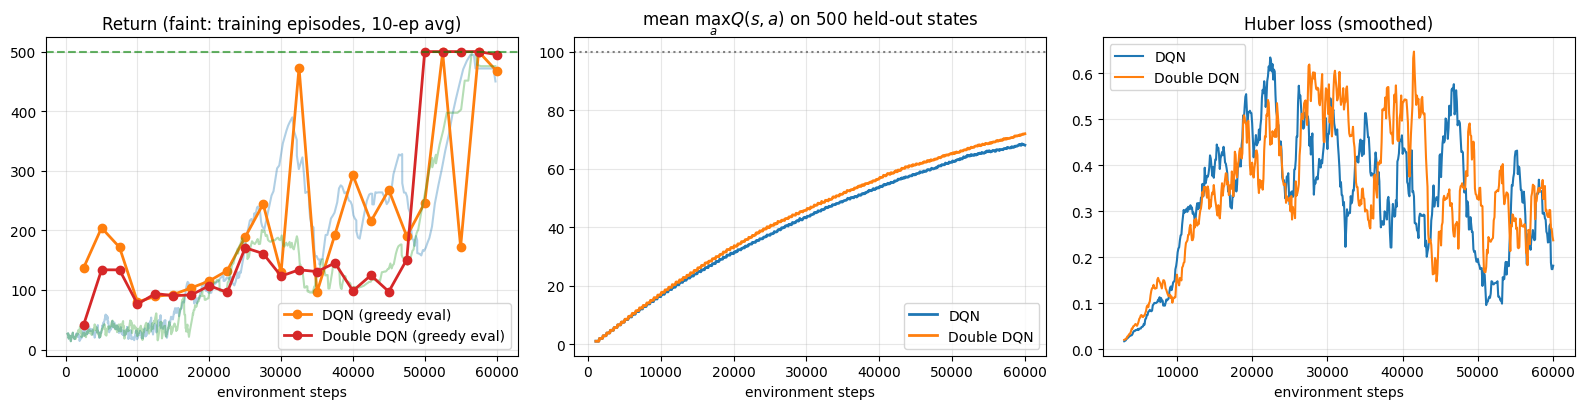

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for name, run in runs.items():
    L = run["logs"]
    axes[0].plot(L["train_return_steps"][9:], moving_average(L["train_returns"], 10), alpha=0.35)
    axes[0].plot(L["eval_step"], L["eval_return"], "o-", lw=2, label=f"{name} (greedy eval)")
    axes[1].plot(L["step"], L["probe_q"], lw=2, label=name)
    axes[2].plot(L["step"][19:], moving_average(L["loss"], 20), lw=1.5, label=name)
axes[0].axhline(500, color="green", ls="--", alpha=0.6); axes[0].set_title("Return (faint: training episodes, 10-ep avg)")
axes[0].set_xlabel("environment steps"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title(r"mean $\max_a Q(s,a)$ on 500 held-out states"); axes[1].set_xlabel("environment steps"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].axhline(1 / (1 - 0.99), color="gray", ls=":", label=r"upper bound $1/(1-\gamma)$")
axes[2].set_title("Huber loss (smoothed)"); axes[2].set_xlabel("environment steps"); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the plots.**

- *Left:* Both agents reach the maximum return; greedy evaluation is much smoother than the $\varepsilon$-greedy training
  returns. Dips after reaching 500 are the well-known DQN instability on CartPole — the reason we keep the best checkpoint.
- *Middle:* The average predicted value on held-out states rises steadily as the policy improves, and is still rising at
  the end of training. With $\gamma = 0.99$ and a reward of 1 per step, the true value of a state under a perfect policy
  is at most $\sum_t 0.99^t \approx 100$ (dotted line), so the estimates are in the right range. On a problem this
  small, DQN and Double DQN track each other closely — the over-estimation gap that Double DQN was designed to close
  is large on Atari (see the paper's Figure 3) but modest here.
- *Right:* The TD loss does not go to zero and does not need to: the targets keep moving as the policy improves.

## 8. Visual Demonstration

We replay the best Double DQN checkpoint and, alongside the frames, plot the two Q-values along the episode. Watch how
$Q(s, \text{left})$ and $Q(s, \text{right})$ cross exactly when the agent switches action — the network has learned a
smooth value landscape over the state space.

Demo agent: best Double DQN checkpoint, greedy eval return over 10 fresh episodes = 500.0


Recorded episode: return 500, length 500


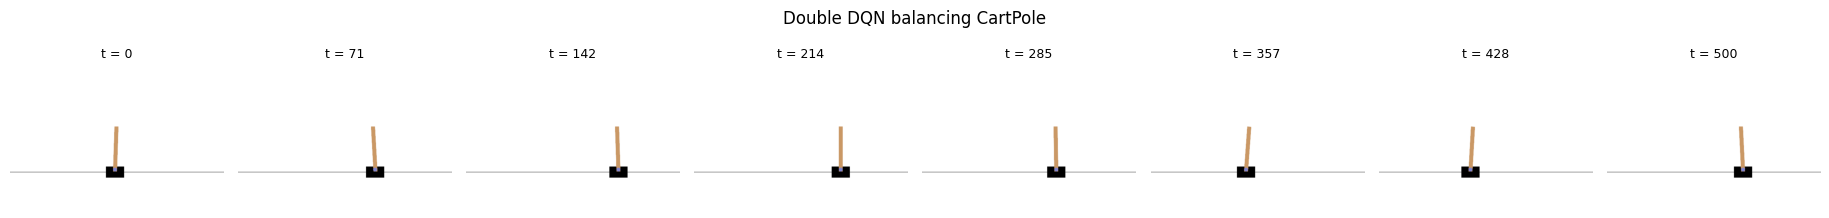

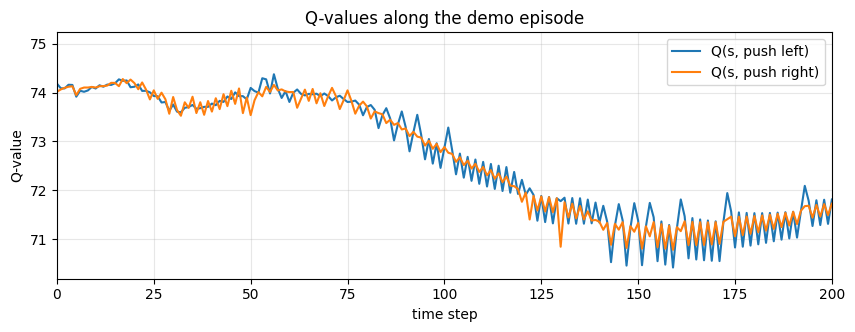

In [11]:
demo_name = "Double DQN" if max(runs["Double DQN"]["logs"]["eval_return"]) >= max(runs["DQN"]["logs"]["eval_return"]) else "DQN"
demo_net = runs[demo_name]["best"]
print(f"Demo agent: best {demo_name} checkpoint, greedy eval return over 10 fresh episodes = {evaluate_greedy(demo_net, 'CartPole-v1', seed=777):.1f}")

q_trace = []
def greedy_with_trace(obs):
    with torch.no_grad():
        q = demo_net(torch.as_tensor(obs, dtype=torch.float32, device=device))
    q_trace.append(q.cpu().numpy())
    return int(q.argmax().item())

render_env = gym.make("CartPole-v1", render_mode="rgb_array")
frames, ep_ret, ep_len = record_episode(render_env, greedy_with_trace, seed=3, max_steps=500)
render_env.close()
print(f"Recorded episode: return {ep_ret:.0f}, length {ep_len}")
show_filmstrip(frames, n=8, title=f"{demo_name} balancing CartPole")

q_trace = np.array(q_trace)
plt.figure(figsize=(10, 3.2))
plt.plot(q_trace[:, 0], label="Q(s, push left)"); plt.plot(q_trace[:, 1], label="Q(s, push right)")
plt.xlabel("time step"); plt.ylabel("Q-value"); plt.title("Q-values along the demo episode"); plt.legend(); plt.grid(alpha=0.3)
plt.xlim(0, min(200, len(q_trace))); plt.show()

Saved media/dqn_cartpole.gif  (167 frames, 0.07 MB)


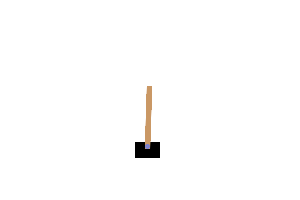

In [12]:
save_gif(frames, "dqn_cartpole", fps=30)

## 9. Strengths, Weaknesses & Connections

### Strengths

- **Off-policy and sample-efficient.** Every transition is reused many times from the replay buffer; DQN needs far
  fewer environment interactions than on-policy policy gradients.
- **Scales to raw perception.** The same algorithm learned 49 Atari games from pixels — the first convincing demonstration
  that deep networks could be trained by RL end-to-end.
- **Simple to implement**, with a single network and no separate policy.

### Weaknesses

- **Discrete actions only.** The $\max_{a'}$ requires enumerating actions; continuous control needs DDPG/TD3/SAC.
- **Over-estimation and instability.** The deadly triad never went away; DQN can diverge or forget, especially with
  large learning rates or small target-update intervals. Double DQN, Huber loss, gradient clipping are all mitigations.
- **Poor exploration.** $\varepsilon$-greedy fails on sparse-reward games like *Montezuma's Revenge* — famously scoring 0.
- **Hyperparameter-sensitive** (learning rate, target update period, buffer size, $\varepsilon$ schedule).
- **Deterministic greedy policy** cannot represent stochastic optimal behavior.

### Connections

- **Q-learning** (Watkins, 1989): the update rule, now with a neural network.
- **Neural Fitted Q Iteration** (Riedmiller, 2005): the batch-mode precursor — fit $Q$ by supervised regression on a
  fixed dataset, iterate.
- **Double DQN** (2016), **Dueling networks** (Wang et al., 2016; $Q = V + A$ decomposition), **Prioritized Experience
  Replay** (Schaul et al., 2016), **Noisy Nets**, **C51 / distributional RL** (Bellemare et al., 2017), **$n$-step returns**:
  combined in **Rainbow** (Hessel et al., 2018).
- **R2D2** (recurrent replay), **Ape-X** (distributed replay), **Agent57** (the first agent above human on all 57 games).
- **DDPG** (next notebooks): DQN's replay buffer and target network transplanted into an actor-critic for continuous actions.
- **Offline RL** (CQL, IQL) and **Decision Transformers** revisit "learn from a fixed replay buffer" as a first-class problem.

## 10. References

1. **Mnih, V., et al.** (2013). *Playing Atari with deep reinforcement learning.* arXiv:1312.5602.
2. **Mnih, V., et al.** (2015). *Human-level control through deep reinforcement learning.* Nature, 518, 529–533.
3. **van Hasselt, H., Guez, A., & Silver, D.** (2016). *Deep reinforcement learning with Double Q-learning.* AAAI.
4. **Lin, L.-J.** (1992). *Self-improving reactive agents based on reinforcement learning, planning and teaching.* Machine Learning, 8.
5. **Riedmiller, M.** (2005). *Neural fitted Q iteration.* ECML.
6. **Wang, Z., et al.** (2016). *Dueling network architectures for deep reinforcement learning.* ICML.
7. **Schaul, T., Quan, J., Antonoglou, I., & Silver, D.** (2016). *Prioritized experience replay.* ICLR.
8. **Hessel, M., et al.** (2018). *Rainbow: Combining improvements in deep reinforcement learning.* AAAI.
9. **Sutton, R. S., & Barto, A. G.** (2018). *Reinforcement Learning: An Introduction* (2nd ed.), §11.3 (the deadly triad).
10. **Huang, S., et al.** (2022). *CleanRL: High-quality single-file implementations of deep RL algorithms.* JMLR.